# Importing Libraries 

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
 
from pathlib import Path
from scipy.stats import poisson
from xgboost import XGBRegressor, XGBClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
base_dir = Path('../artifacts')
PROCESSED_DIR   = base_dir / 'processed_data'
MODEL_DIR       = base_dir / 'models'
FIGURE_DIR      = base_dir / 'figures'
FEATURE_DIR     = base_dir / 'features'
METRICS_DIR     = base_dir / 'metrics'
INTERIM_DIR     = base_dir / 'interim_data'
PREDICTIONS_DIR = base_dir / 'predictions'
 
directories = [PROCESSED_DIR, MODEL_DIR, FIGURE_DIR, FEATURE_DIR,
               METRICS_DIR, INTERIM_DIR, PREDICTIONS_DIR]
 
for path in directories:
    path.mkdir(parents=True, exist_ok=True)
 

# Loading the Data

In [3]:
df = pd.read_csv(f'{PROCESSED_DIR}/xgboost_features.csv', parse_dates=['date'])
print(df.shape)
print(df.dtypes)

(49233, 98)
date                   datetime64[us]
home_team                         str
away_team                         str
home_goals                    float64
away_goals                    float64
                            ...      
away_wc_appearances             int64
home_wc_titles                  int64
away_wc_titles                  int64
home_wc_qf_matches              int64
away_wc_qf_matches              int64
Length: 98, dtype: object


In [4]:
df.head()

,date,home_team,away_team,home_goals,away_goals,home_win,away_win,draw,goal_diff,result,...,home_conf_strength,away_conf_strength,conf_strength_diff,home_tournament_stage,home_wc_appearances,away_wc_appearances,home_wc_titles,away_wc_titles,home_wc_qf_matches,away_wc_qf_matches
0,1872-11-30,Scotland,England,0.0,0.0,0,0,1,0.0,1,...,6,6,0,0,0,0,0,1,0,0
1,1873-03-08,England,Scotland,4.0,2.0,1,0,0,2.0,0,...,6,6,0,0,0,0,1,0,0,0
2,1874-03-07,Scotland,England,2.0,1.0,1,0,0,1.0,0,...,6,6,0,0,0,0,0,1,0,0
3,1875-03-06,England,Scotland,2.0,2.0,0,0,1,0.0,1,...,6,6,0,0,0,0,1,0,0,0
4,1876-03-04,Scotland,England,3.0,0.0,1,0,0,3.0,0,...,6,6,0,0,0,0,0,1,0,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49233 entries, 0 to 49232
Data columns (total 98 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   date                        49233 non-null  datetime64[us]
 1   home_team                   49233 non-null  str           
 2   away_team                   49233 non-null  str           
 3   home_goals                  49233 non-null  float64       
 4   away_goals                  49233 non-null  float64       
 5   home_win                    49233 non-null  int64         
 6   away_win                    49233 non-null  int64         
 7   draw                        49233 non-null  int64         
 8   goal_diff                   49233 non-null  float64       
 9   result                      49233 non-null  int64         
 10  is_competitive              49233 non-null  bool          
 11  home_elo                    49233 non-null  float64       
 12  a

# Feature Columns 

In [6]:
META_COLS   = ['date', 'home_team', 'away_team', 'tournament']
TARGET_COLS = ['home_goals', 'away_goals', 'home_win', 'draw',
               'away_win', 'goal_diff', 'result', 'is_competitive']
 
FEATURE_COLS = [c for c in df.columns if c not in META_COLS + TARGET_COLS]
 
print(f"\nFeatures used : {len(FEATURE_COLS)}")
print(FEATURE_COLS)


Features used : 87
['home_elo', 'away_elo', 'elo_diff', 'home_rank', 'away_rank', 'rank_diff', 'neutral', 'host_advantage', 'home_last3_wins', 'home_last3_draws', 'home_last3_losses', 'home_last3_goals_scored', 'home_last3_goals_conceded', 'away_last3_wins', 'away_last3_draws', 'away_last3_losses', 'away_last3_goals_scored', 'away_last3_goals_conceded', 'diff_last3_goals_scored', 'diff_last3_goals_conceded', 'diff_last3_win_rate', 'home_last5_wins', 'home_last5_draws', 'home_last5_losses', 'home_last5_goals_scored', 'home_last5_goals_conceded', 'home_last5_goal_diff', 'home_last5_ppm', 'home_last5_win_rate', 'home_last5_clean_sheets', 'home_last5_conceded_2plus', 'home_last5_scored_2plus', 'away_last5_wins', 'away_last5_draws', 'away_last5_losses', 'away_last5_goals_scored', 'away_last5_goals_conceded', 'away_last5_goal_diff', 'away_last5_ppm', 'away_last5_win_rate', 'away_last5_clean_sheets', 'away_last5_conceded_2plus', 'away_last5_scored_2plus', 'diff_last5_goals_scored', 'diff_las

# Train / Valid Split 

In [7]:
if 'is_competitive' not in df.columns:
    df['is_competitive'] = True
 
train_df = df[df['is_competitive'] & (df['date'] >= '2000-01-01')].copy()
 
train = train_df[train_df['date'] <  '2024-01-01'].copy()
valid = train_df[train_df['date'] >= '2024-01-01'].copy()
 
print(f"\nTrain : {len(train):,} matches  ({train['date'].dt.year.min()}–{train['date'].dt.year.max()})")
print(f"Valid : {len(valid):,} matches  ({valid['date'].dt.year.min()}–{valid['date'].dt.year.max()})")


Train : 14,855 matches  (2000–2023)
Valid : 1,776 matches  (2024–2026)


In [8]:
X_train = train[FEATURE_COLS].fillna(0)
X_valid = valid[FEATURE_COLS].fillna(0)
 
y_train_home = train['home_goals']
y_train_away = train['away_goals']
y_valid_home = valid['home_goals']
y_valid_away = valid['away_goals']

# Sample Weights for Training 

In [9]:
def compute_weights(dates, reference_date, half_life_days=365.0):
    lam      = np.log(2) / half_life_days
    days_ago = (reference_date - dates).dt.days.values
    return np.exp(-lam * days_ago)
 
reference_date = train['date'].max()
sample_weights = compute_weights(train['date'], reference_date, half_life_days=365)
 
print(f"\nSample weight range : {sample_weights.min():.4f} – {sample_weights.max():.4f}")
print(f"Reference date      : {reference_date.date()}")


Sample weight range : 0.0000 – 1.0000
Reference date      : 2023-12-02


# Train XGBoost Models 

In [10]:

 
params_home = dict(
    objective       = 'count:poisson',  
    n_estimators    = 500,
    learning_rate   = 0.05,
    max_depth       = 4,
    subsample       = 0.8,
    colsample_bytree= 0.8,
    min_child_weight= 5,
    reg_alpha       = 0.1,             
    reg_lambda      = 1.0,            
    random_state    = 42,
    n_jobs          = -1,
)
 
params_away = dict(
    objective       = 'count:poisson',
    n_estimators    = 500,
    learning_rate   = 0.05,
    max_depth       = 4,
    subsample       = 0.8,
    colsample_bytree= 0.8,
    min_child_weight= 5,
    reg_alpha       = 0.1,
    reg_lambda      = 1.0,
    random_state    = 42,
    n_jobs          = -1,
)
 

 

In [11]:
print("\nTraining XGBoost home goals model...")
model_home = XGBRegressor(**params_home)
model_home.fit(
    X_train, y_train_home,
    sample_weight=sample_weights,
    eval_set=[(X_valid, y_valid_home)],
    verbose=50,
)
 




Training XGBoost home goals model...
[0]	validation_0-poisson-nloglik:1.71845
[50]	validation_0-poisson-nloglik:1.54017
[100]	validation_0-poisson-nloglik:1.51742
[150]	validation_0-poisson-nloglik:1.51344
[200]	validation_0-poisson-nloglik:1.51517
[250]	validation_0-poisson-nloglik:1.51609
[300]	validation_0-poisson-nloglik:1.51694
[350]	validation_0-poisson-nloglik:1.51815
[400]	validation_0-poisson-nloglik:1.51881
[450]	validation_0-poisson-nloglik:1.52127
[499]	validation_0-poisson-nloglik:1.52299


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'count:poisson'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load

In [12]:
print("\nTraining XGBoost away goals model...")
model_away = XGBRegressor(**params_away)
model_away.fit(
    X_train, y_train_away,
    sample_weight=sample_weights,
    eval_set=[(X_valid, y_valid_away)],
    verbose=50,
)
 


Training XGBoost away goals model...
[0]	validation_0-poisson-nloglik:1.49756
[50]	validation_0-poisson-nloglik:1.35073
[100]	validation_0-poisson-nloglik:1.33603
[150]	validation_0-poisson-nloglik:1.33716
[200]	validation_0-poisson-nloglik:1.34015
[250]	validation_0-poisson-nloglik:1.34183
[300]	validation_0-poisson-nloglik:1.34409
[350]	validation_0-poisson-nloglik:1.34497
[400]	validation_0-poisson-nloglik:1.34674
[450]	validation_0-poisson-nloglik:1.34881
[499]	validation_0-poisson-nloglik:1.35067


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'count:poisson'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load

# Predict on Validation Set 

In [13]:
valid = valid.copy()
valid['pred_home_goals'] = model_home.predict(X_valid)
valid['pred_away_goals'] = model_away.predict(X_valid)
 
# Clip to non-negative (Poisson objective handles this but just in case)
valid['pred_home_goals'] = valid['pred_home_goals'].clip(0)
valid['pred_away_goals'] = valid['pred_away_goals'].clip(0)
 
print("\nSample predictions:")
print(valid[[
    'date', 'home_team', 'away_team',
    'home_goals', 'pred_home_goals',
    'away_goals', 'pred_away_goals'
]].head(10).to_string(index=False))


Sample predictions:
      date            home_team         away_team  home_goals  pred_home_goals  away_goals  pred_away_goals
2024-01-12                Qatar           Lebanon         3.0         2.237921         0.0         0.510147
2024-01-13                China        Tajikistan         0.0         1.703789         0.0         0.955950
2024-01-13            Australia             India         2.0         2.586826         0.0         0.325138
2024-01-13           Uzbekistan             Syria         0.0         2.165721         0.0         0.661440
2024-01-13          Ivory Coast     Guinea-Bissau         2.0         3.016239         0.0         0.792702
2024-01-14              Nigeria Equatorial Guinea         1.0         1.660006         1.0         0.992935
2024-01-14                Japan           Vietnam         4.0         3.739131         2.0         0.413652
2024-01-14                Egypt        Mozambique         2.0         2.338810         2.0         0.585200
2024-01

# Goal Prediction Metrics 

In [14]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))
 
mae_home  = mean_absolute_error(y_valid_home, valid['pred_home_goals'])
mae_away  = mean_absolute_error(y_valid_away, valid['pred_away_goals'])
rmse_home = rmse(y_valid_home, valid['pred_home_goals'])
rmse_away = rmse(y_valid_away, valid['pred_away_goals'])
 
# Baseline: always predict training mean
baseline_home = np.full(len(valid), y_train_home.mean())
baseline_away = np.full(len(valid), y_train_away.mean())
 
print("\n Goal Prediction Metrics ")
print(f"  Home goals  →  MAE: {mae_home:.4f}  |  RMSE: {rmse_home:.4f}")
print(f"  Away goals  →  MAE: {mae_away:.4f}  |  RMSE: {rmse_away:.4f}")
 
print("\n Baseline (always predict training mean) ")
print(f"  Home goals  →  MAE: {mean_absolute_error(y_valid_home, baseline_home):.4f}  |  RMSE: {rmse(y_valid_home, baseline_home):.4f}")
print(f"  Away goals  →  MAE: {mean_absolute_error(y_valid_away, baseline_away):.4f}  |  RMSE: {rmse(y_valid_away, baseline_away):.4f}")
 
print(f"\n  Mean pred home : {valid['pred_home_goals'].mean():.3f}  (actual: {y_valid_home.mean():.3f})")
print(f"  Mean pred away : {valid['pred_away_goals'].mean():.3f}  (actual: {y_valid_away.mean():.3f})")


 Goal Prediction Metrics 
  Home goals  →  MAE: 1.0107  |  RMSE: 1.3292
  Away goals  →  MAE: 0.8577  |  RMSE: 1.1467

 Baseline (always predict training mean) 
  Home goals  →  MAE: 1.2397  |  RMSE: 1.5768
  Away goals  →  MAE: 0.9799  |  RMSE: 1.3234

  Mean pred home : 1.524  (actual: 1.588)
  Mean pred away : 1.099  (actual: 1.158)


# Scatter — Predicted vs Actual Goals

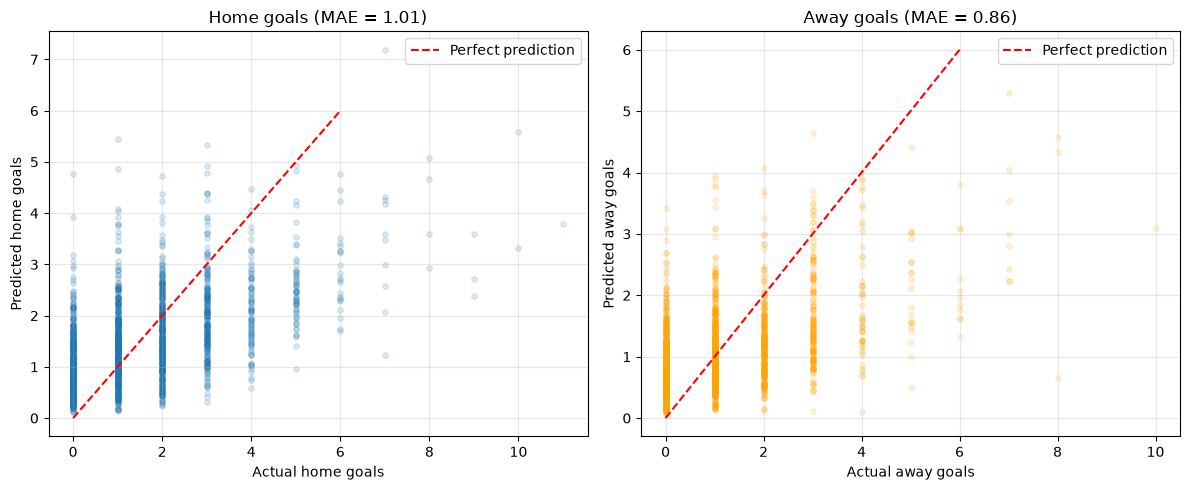

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
 
axes[0].scatter(y_valid_home, valid['pred_home_goals'], alpha=0.15, s=15)
axes[0].plot([0, 6], [0, 6], 'r--', label='Perfect prediction')
axes[0].set_xlabel('Actual home goals')
axes[0].set_ylabel('Predicted home goals')
axes[0].set_title(f'Home goals (MAE = {mae_home:.2f})')
axes[0].legend()
axes[0].grid(alpha=0.3)
 
axes[1].scatter(y_valid_away, valid['pred_away_goals'], alpha=0.15, s=15, color='orange')
axes[1].plot([0, 6], [0, 6], 'r--', label='Perfect prediction')
axes[1].set_xlabel('Actual away goals')
axes[1].set_ylabel('Predicted away goals')
axes[1].set_title(f'Away goals (MAE = {mae_away:.2f})')
axes[1].legend()
axes[1].grid(alpha=0.3)
 
plt.tight_layout()
plt.show()

# Derive Win/Draw/Loss Probabilities via Score Grid

In [16]:
MAX_GOALS = 10
 
def score_grid_probabilities(lambda_home: float, lambda_away: float):
    """
    Derive win/draw/loss probabilities from expected goals
    using Poisson score grid.
    """
    p_home = np.array([poisson.pmf(i, lambda_home) for i in range(MAX_GOALS)])
    p_away = np.array([poisson.pmf(i, lambda_away) for i in range(MAX_GOALS)])
    grid   = np.outer(p_home, p_away)   # [i,j] = P(home=i, away=j)
 
    p_home_win = np.tril(grid, k=-1).sum()   # home goals > away goals
    p_draw     = np.trace(grid)               # home goals == away goals
    p_away_win = np.triu(grid, k=1).sum()    # away goals > home goals
 
    return p_home_win, p_draw, p_away_win
 
 
probs = valid.apply(
    lambda r: score_grid_probabilities(r['pred_home_goals'], r['pred_away_goals']),
    axis=1, result_type='expand'
)
probs.columns = ['prob_home_win', 'prob_draw', 'prob_away_win']
valid = pd.concat([valid, probs], axis=1)

# Outcome Evaluation 

In [17]:
def predict_outcome(p_home, p_draw, p_away, draw_threshold=0.28):
    """
    0 = Home Win, 1 = Draw, 2 = Away Win
    If draw probability exceeds threshold → predict draw.
    Otherwise take argmax of home/away.
    """
    if p_draw >= draw_threshold:
        return 1
    return 0 if p_home >= p_away else 2
 
 
def evaluate_outcome(df, draw_threshold=0.28):
    """Full evaluation: accuracy + confusion matrix + classification report."""
    df = df.copy()
    df['pred_result'] = df.apply(
        lambda r: predict_outcome(
            r['prob_home_win'], r['prob_draw'], r['prob_away_win'],
            draw_threshold
        ), axis=1
    )
 
    accuracy = (df['pred_result'] == df['result']).mean()
    print(f"\n Outcome Accuracy (draw_threshold={draw_threshold:.2f}) ")
    print(f"  Correct outcome predicted: {accuracy:.2%}")
 
    cm = confusion_matrix(df['result'], df['pred_result'], labels=[0, 1, 2])
    print("\n Confusion Matrix (rows=actual, cols=predicted)")
    print(pd.DataFrame(
        cm,
        index  =['Actual HW', 'Actual Draw', 'Actual AW'],
        columns=['Pred HW',   'Pred Draw',   'Pred AW']
    ))
 
    print("\n Classification Report ")
    print(classification_report(
        df['result'], df['pred_result'],
        target_names=['HomeWin', 'Draw', 'AwayWin'],
        zero_division=0
    ))
    return df['pred_result'] 
 


In [18]:
print(valid[['prob_home_win', 'prob_draw', 'prob_away_win']].head())

print(valid[['prob_home_win', 'prob_draw', 'prob_away_win']].isna().sum())

       prob_home_win  prob_draw  prob_away_win
46732       0.769639   0.160894       0.069352
46734       0.549630   0.239635       0.210723
46735       0.858565   0.110660       0.030413
46736       0.720474   0.179608       0.099829
46737       0.814945   0.116676       0.067232
prob_home_win    0
prob_draw        0
prob_away_win    0
dtype: int64


In [19]:
 
# Default argmax
print("=" * 60)
print("DEFAULT: argmax ")
print("=" * 60)
 
valid['pred_result'] = valid[['prob_home_win', 'prob_draw', 'prob_away_win']].idxmax(axis=1)
valid['pred_result'] = valid['pred_result'].map({
    'prob_home_win': 0,
    'prob_draw':     1,
    'prob_away_win': 2,
})
 
accuracy = (valid['pred_result'] == valid['result']).mean()
print(f"\n  Correct outcome predicted: {accuracy:.2%}")
 
cm = confusion_matrix(valid['result'], valid['pred_result'], labels=[0, 1, 2])
print("\n Confusion Matrix ")
print(pd.DataFrame(
    cm,
    index  =['Actual HW', 'Actual Draw', 'Actual AW'],
    columns=['Pred HW',   'Pred Draw',   'Pred AW']
))
print("\n Classification Report ")
print(classification_report(
    valid['result'], valid['pred_result'],
    target_names=['HomeWin', 'Draw', 'AwayWin'],
    zero_division=0
))

DEFAULT: argmax 

  Correct outcome predicted: 60.47%

 Confusion Matrix 
             Pred HW  Pred Draw  Pred AW
Actual HW        694          3      128
Actual Draw      249          1      163
Actual AW        157          2      379

 Classification Report 
              precision    recall  f1-score   support

     HomeWin       0.63      0.84      0.72       825
        Draw       0.17      0.00      0.00       413
     AwayWin       0.57      0.70      0.63       538

    accuracy                           0.60      1776
   macro avg       0.45      0.52      0.45      1776
weighted avg       0.50      0.60      0.53      1776



In [20]:
# Threshold tuning
print("\n" + "=" * 60)
print("TUNING: Find best draw threshold")
print("=" * 60)
 
thresholds = np.arange(0.20, 0.45, 0.01)
results    = []
 
for thresh in thresholds:
    preds = valid.apply(
        lambda r: predict_outcome(
            r['prob_home_win'], r['prob_draw'], r['prob_away_win'], thresh
        ), axis=1
    )
    acc       = (preds == valid['result']).mean()
    draw_rate = (preds == 1).mean()
    results.append({
        'threshold':      round(thresh, 2),
        'accuracy':       round(acc, 4),
        'pred_draw_rate': round(draw_rate, 4),
    })
 
df_thresh   = pd.DataFrame(results)
best_row    = df_thresh.loc[df_thresh['accuracy'].idxmax()]
best_thresh = best_row['threshold']
best_acc    = best_row['accuracy']
 
print(f"\n  Actual draw rate in validation : {(valid['result'] == 1).mean():.2%}")
print(f"\n  Best threshold : {best_thresh:.2f}")
print(f"  Best accuracy  : {best_acc:.2%}")
print(f"\n  Threshold scan:")
print(df_thresh.to_string(index=False))
 


TUNING: Find best draw threshold

  Actual draw rate in validation : 23.25%

  Best threshold : 0.34
  Best accuracy  : 60.70%

  Threshold scan:
 threshold  accuracy  pred_draw_rate
      0.20    0.4792          0.6408
      0.21    0.4966          0.6120
      0.22    0.5090          0.5743
      0.23    0.5203          0.5253
      0.24    0.5372          0.4752
      0.25    0.5535          0.4144
      0.26    0.5726          0.3435
      0.27    0.5811          0.2759
      0.28    0.5918          0.2111
      0.29    0.6019          0.1498
      0.30    0.6042          0.0884
      0.31    0.6064          0.0512
      0.32    0.6059          0.0293
      0.33    0.6064          0.0180
      0.34    0.6070          0.0113
      0.35    0.6053          0.0051
      0.36    0.6053          0.0017
      0.37    0.6053          0.0006
      0.38    0.6053          0.0000
      0.39    0.6053          0.0000
      0.40    0.6053          0.0000
      0.41    0.6053          0.0000
  

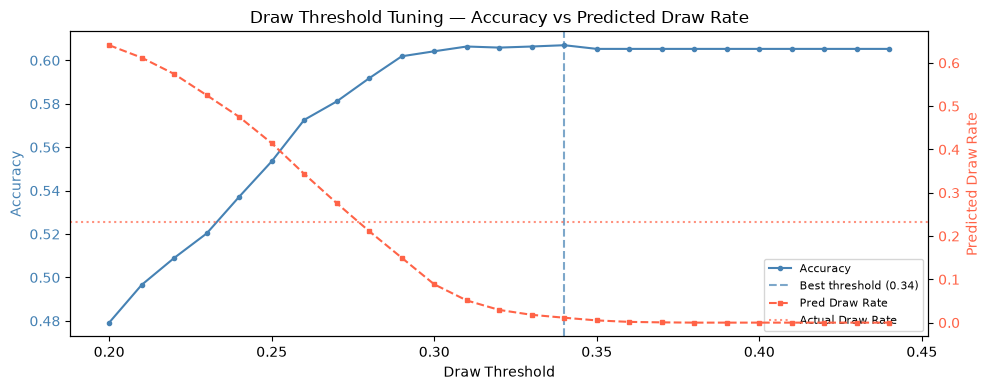

In [21]:
# Threshold tuning plot
fig, ax1 = plt.subplots(figsize=(10, 4))
 
ax1.plot(df_thresh['threshold'], df_thresh['accuracy'],
         color='steelblue', marker='o', markersize=3, label='Accuracy')
ax1.axvline(best_thresh, color='steelblue', linestyle='--', alpha=0.7,
            label=f'Best threshold ({best_thresh:.2f})')
ax1.set_xlabel('Draw Threshold')
ax1.set_ylabel('Accuracy', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
 
ax2 = ax1.twinx()
ax2.plot(df_thresh['threshold'], df_thresh['pred_draw_rate'],
         color='tomato', marker='s', markersize=3, linestyle='--',
         label='Pred Draw Rate')
ax2.axhline((valid['result'] == 1).mean(), color='tomato', linestyle=':',
            alpha=0.7, label='Actual Draw Rate')
ax2.set_ylabel('Predicted Draw Rate', color='tomato')
ax2.tick_params(axis='y', labelcolor='tomato')
 
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right', fontsize=8)
 
plt.title('Draw Threshold Tuning — Accuracy vs Predicted Draw Rate')
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/xgb_threshold_tuning.png', dpi=150)
plt.show()

In [22]:
# Final evaluation with best threshold
print("\n" + "=" * 60)
print(f"FINAL EVALUATION — draw_threshold = {best_thresh:.2f}")
print("=" * 60)
 
final_preds = evaluate_outcome(valid, draw_threshold=best_thresh)
valid['pred_result'] = final_preds


FINAL EVALUATION — draw_threshold = 0.34

 Outcome Accuracy (draw_threshold=0.34) 
  Correct outcome predicted: 60.70%

 Confusion Matrix (rows=actual, cols=predicted)
             Pred HW  Pred Draw  Pred AW
Actual HW        693          5      127
Actual Draw      244          9      160
Actual AW        156          6      376

 Classification Report 
              precision    recall  f1-score   support

     HomeWin       0.63      0.84      0.72       825
        Draw       0.45      0.02      0.04       413
     AwayWin       0.57      0.70      0.63       538

    accuracy                           0.61      1776
   macro avg       0.55      0.52      0.46      1776
weighted avg       0.57      0.61      0.54      1776



# Goal Distribution

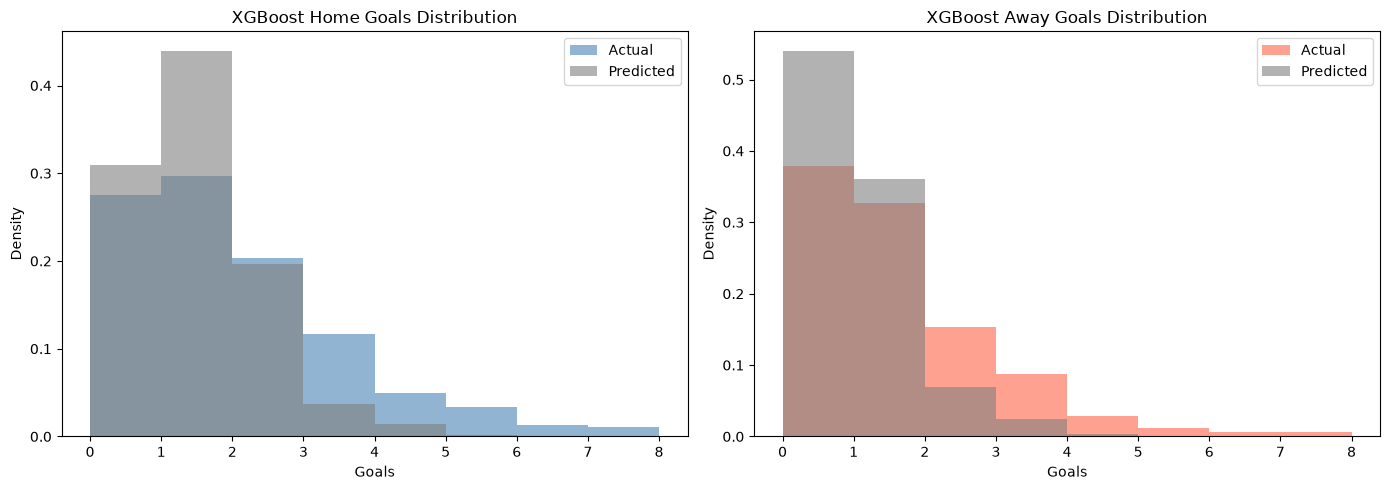

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
for ax, col_actual, col_pred, title, color in [
    (axes[0], 'home_goals', 'pred_home_goals', 'Home Goals', 'steelblue'),
    (axes[1], 'away_goals', 'pred_away_goals', 'Away Goals', 'tomato'),
]:
    ax.hist(valid[col_actual].clip(0, 7), bins=range(9),
            alpha=0.6, label='Actual', color=color, density=True)
    ax.hist(valid[col_pred].clip(0, 7), bins=range(9),
            alpha=0.6, label='Predicted', color='gray', density=True)
    ax.set_title(f'XGBoost {title} Distribution')
    ax.set_xlabel('Goals')
    ax.set_ylabel('Density')
    ax.legend()
 
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/xgb_goal_distribution.png', dpi=150)
plt.show()

# Feature Importance


── Top 20 Features — Home Goals Model ───────────────────


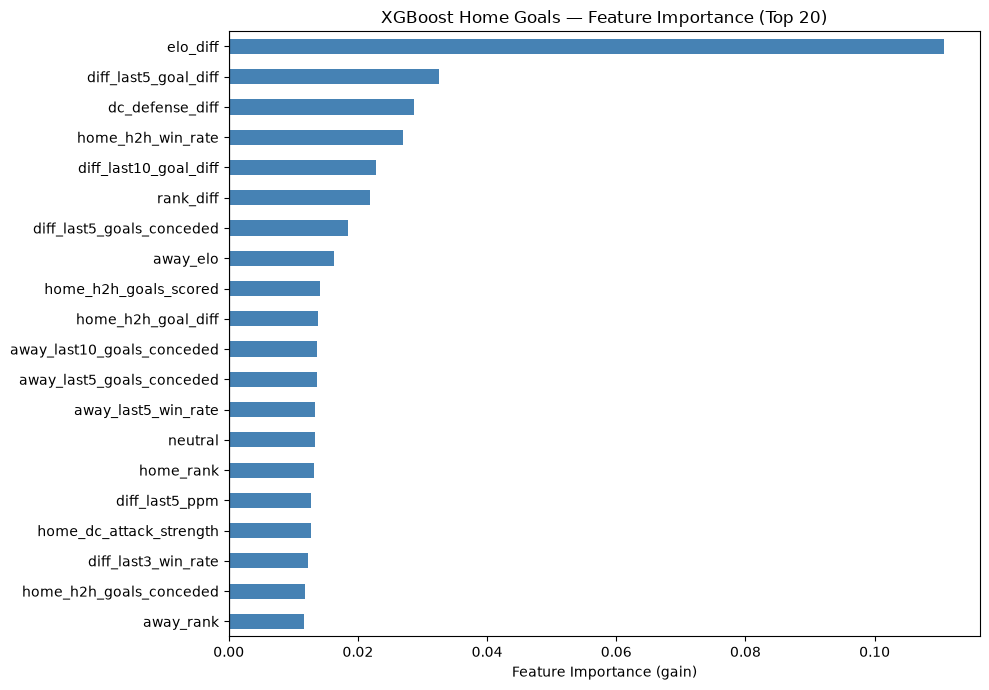

elo_diff                      0.110773
diff_last5_goal_diff          0.032554
dc_defense_diff               0.028639
home_h2h_win_rate             0.026967
diff_last10_goal_diff         0.022743
rank_diff                     0.021911
diff_last5_goals_conceded     0.018448
away_elo                      0.016357
home_h2h_goals_scored         0.014141
home_h2h_goal_diff            0.013786
away_last10_goals_conceded    0.013675
away_last5_goals_conceded     0.013610
away_last5_win_rate           0.013393
neutral                       0.013310
home_rank                     0.013232
diff_last5_ppm                0.012778
home_dc_attack_strength       0.012693
diff_last3_win_rate           0.012207
home_h2h_goals_conceded       0.011794
away_rank                     0.011655

── Top 20 Features — Away Goals Model ───────────────────


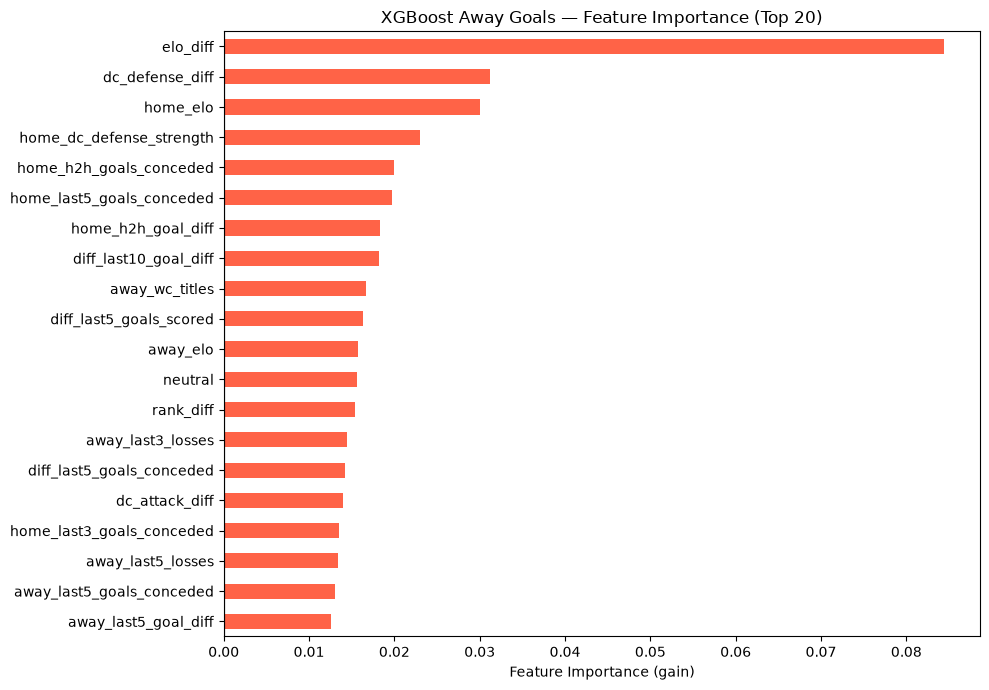

elo_diff                     0.084410
dc_defense_diff              0.031260
home_elo                     0.030041
home_dc_defense_strength     0.022970
home_h2h_goals_conceded      0.019998
home_last5_goals_conceded    0.019779
home_h2h_goal_diff           0.018348
diff_last10_goal_diff        0.018171
away_wc_titles               0.016715
diff_last5_goals_scored      0.016290
away_elo                     0.015681
neutral                      0.015662
rank_diff                    0.015375
away_last3_losses            0.014396
diff_last5_goals_conceded    0.014166
dc_attack_diff               0.014033
home_last3_goals_conceded    0.013560
away_last5_losses            0.013436
away_last5_goals_conceded    0.013097
away_last5_goal_diff         0.012630


In [24]:
def plot_feature_importance(model, feature_cols, title, filename,
                             top_n=20, color='steelblue'):
    importance = pd.Series(
        model.feature_importances_, index=feature_cols
    ).sort_values(ascending=False).head(top_n)
 
    fig, ax = plt.subplots(figsize=(10, 7))
    importance.sort_values().plot(kind='barh', ax=ax, color=color)
    ax.set_title(title)
    ax.set_xlabel('Feature Importance (gain)')
    ax.axvline(0, color='black', linewidth=0.8)
    plt.tight_layout()
    plt.savefig(f'{FIGURE_DIR}/{filename}', dpi=150)
    plt.show()
 
    return importance
 
 
print("\n── Top 20 Features — Home Goals Model ───────────────────")
imp_home = plot_feature_importance(
    model_home, FEATURE_COLS,
    'XGBoost Home Goals — Feature Importance (Top 20)',
    'xgb_importance_home.png', color='steelblue'
)
print(imp_home.to_string())
 
print("\n── Top 20 Features — Away Goals Model ───────────────────")
imp_away = plot_feature_importance(
    model_away, FEATURE_COLS,
    'XGBoost Away Goals — Feature Importance (Top 20)',
    'xgb_importance_away.png', color='tomato'
)
print(imp_away.to_string())

# Learning Curves

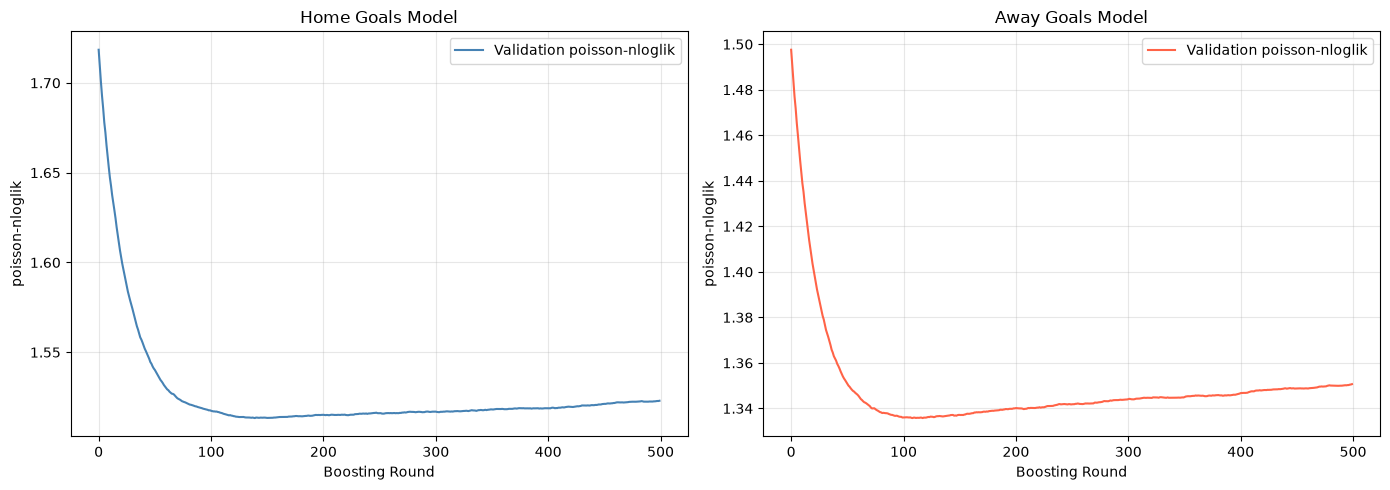

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, model, title, color in [
    (axes[0], model_home, 'Home Goals Model', 'steelblue'),
    (axes[1], model_away, 'Away Goals Model', 'tomato'),
]:

    results = model.evals_result()

    # Get validation dataset name
    eval_set = list(results.keys())[0]

    # Get metric name automatically
    metric = list(results[eval_set].keys())[0]

    values = results[eval_set][metric]

    epochs = len(values)

    ax.plot(
        range(epochs),
        values,
        color=color,
        label=f'Validation {metric}'
    )

    if hasattr(model, "best_iteration"):
        ax.axvline(
            model.best_iteration,
            color='black',
            linestyle='--',
            alpha=0.7,
            label=f'Best iteration ({model.best_iteration})'
        )

    ax.set_xlabel('Boosting Round')
    ax.set_ylabel(metric)
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    f'{FIGURE_DIR}/xgb_learning_curves.png',
    dpi=150,
    bbox_inches="tight"
)

plt.show()
 

# Saving the Model 

In [28]:
 
# Models
joblib.dump(model_home, f'{MODEL_DIR}/xgb_home.pkl')
joblib.dump(model_away, f'{MODEL_DIR}/xgb_away.pkl')
 
# Feature column order — critical for consistent inference
pd.Series(FEATURE_COLS).to_csv(f'{FEATURE_DIR}/xgb_feature_cols.csv', index=False)
 
# Threshold config
thresh_cfg = {
    'draw_threshold':      float(best_thresh),
    'validation_accuracy': float(best_acc),
    'actual_draw_rate':    round((valid['result'] == 1).mean(), 4),
}
with open(f'{METRICS_DIR}/xgb_threshold.json', 'w') as f:
    json.dump(thresh_cfg, f, indent=2)
 
# Feature importance tables
imp_home.reset_index().rename(columns={'index': 'feature', 0: 'importance'}) \
    .to_csv(f'{INTERIM_DIR}/xgb_importance_home.csv', index=False)
imp_away.reset_index().rename(columns={'index': 'feature', 0: 'importance'}) \
    .to_csv(f'{INTERIM_DIR}/xgb_importance_away.csv', index=False)
 
# Validation predictions
valid_preds = valid[['date', 'home_team', 'away_team',
                      'home_goals', 'away_goals', 'result',
                      'pred_home_goals', 'pred_away_goals',
                      'prob_home_win', 'prob_draw', 'prob_away_win',
                      'pred_result']].copy()
 
valid_preds.to_csv(f'{PREDICTIONS_DIR}/xgb_valid_preds.csv', index=False)
 
print("\nSaved:")
print(f"  models/       → xgb_home.pkl, xgb_away.pkl")
print(f"  features/     → xgb_feature_cols.csv")
print(f"  metrics/      → xgb_threshold.json")
print(f"  interim_data/ → xgb_importance_home.csv, xgb_importance_away.csv")
print(f"  predictions/  → xgb_valid_preds.csv")
print(json.dumps(thresh_cfg, indent=2))


Saved:
  models/       → xgb_home.pkl, xgb_away.pkl
  features/     → xgb_feature_cols.csv
  metrics/      → xgb_threshold.json
  interim_data/ → xgb_importance_home.csv, xgb_importance_away.csv
  predictions/  → xgb_valid_preds.csv
{
  "draw_threshold": 0.34,
  "validation_accuracy": 0.607,
  "actual_draw_rate": 0.2325
}
